# Task 1: Read an XYZ file

In this warm-up task, we read a tiny molecule file and compute the geometric centroid of the atoms.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
print('Imports successful')

Imports successful


## The XYZ format

An XYZ file is a simple text file for molecular coordinates.

- The first line contains the number of atoms.
- The second line is a comment.
- Each following line contains an element symbol and three coordinates: `x y z`.

For this exercise, the file is called `water.xyz`.

## Your task

Write a function `read_xyz(path)` that returns two things:

1. a list of element symbols, for example `['O', 'H', 'H']`
2. a NumPy array with shape `(N, 3)` containing the coordinates

Then read `water.xyz` and compute the geometric centroid:

```python
centroid = coordinates.mean(axis=0)
```

## Your solution

In [2]:
def read_xyz(path):
    """Read an XYZ file and return element symbols and coordinates."""
    with open(path, 'r') as f:
        n_atoms = int(f.readline().strip())
        f.readline()  # Skip comment line
        
        elements = []
        coords = []
        for _ in range(n_atoms):
            parts = f.readline().strip().split()
            elements.append(parts[0])
            coords.append([float(x) for x in parts[1:4]])
    
    return elements, np.array(coords)

# Read water.xyz
elements, coordinates = read_xyz('water.xyz')
print(f"Elements: {elements}")
print(f"Coordinates:\n{coordinates}")

# Compute centroid
centroid = coordinates.mean(axis=0)
print(f"Centroid: {centroid}")

Elements: ['O', 'H', 'H']
Coordinates:
[[ 0.     0.     0.   ]
 [ 0.     0.757  0.586]
 [ 0.    -0.757  0.586]]
Centroid: [0.         0.         0.39066667]


## Extra task: plot the molecule

Make a simple plot of the atoms in the `y z` plane.

- Use the second coordinate column for `y`.
- Use the third coordinate column for `z`.
- Add the element symbols as labels.
- Mark the geometric centroid.

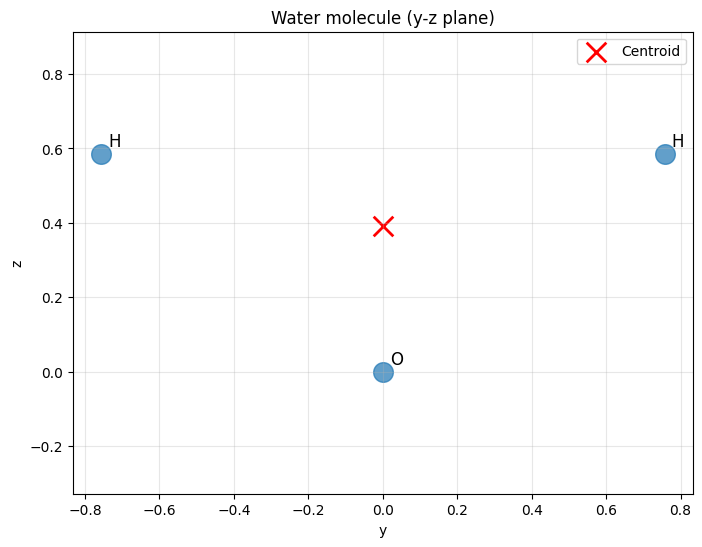

In [3]:
# Plot the molecule in the y-z plane
plt.figure(figsize=(8, 6))

# Plot atoms
plt.scatter(coordinates[:, 1], coordinates[:, 2], s=200, alpha=0.7)

# Add element labels
for i, element in enumerate(elements):
    plt.annotate(element, (coordinates[i, 1], coordinates[i, 2]), 
                xytext=(5, 5), textcoords='offset points', fontsize=12)

# Mark the centroid
plt.scatter(centroid[1], centroid[2], marker='x', s=200, color='red', linewidths=2, label='Centroid')

plt.xlabel('y')
plt.ylabel('z')
plt.title('Water molecule (y-z plane)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()